In [50]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from xgboost import XGBRegressor
import sys
sys.path.insert(0, '../../Functions')
from lstm_model import build_and_evaluate_model, prepare_lstm_data, set_seed
from plot_placement import plot_song_prediction_comparison_lstm, plot_xgboost_lstm_comparison, plot_song_prediction_comparison
import joblib
from sklearn.preprocessing import MinMaxScaler

from keras.models import load_model

In [47]:
#get data and models
lstm_data = pd.read_csv("../../Data/prepared_lstm_data.csv") # Load prepared data for LSTM model
xgboost_data = pd.read_csv("../../Data/processed_forecast_data.csv") # Load processed data for XGBoost model
lstm_model = load_model("../Models/LSTM_improved.keras") # Load the trained LSTM model
xgboost_model = joblib.load("../Models/xgboost_next_week.pkl") # Load the trained XGBoost model

PLOT LSTM RESULTS



In [27]:
SEQ_LEN = 4
groups = lstm_data.groupby(['Song', 'Artist'])

X = []
y = []
target_dates = []
meta = []

features = [
    'Rank',
    'Last Week',
    'Weeks in Charts',
    'rank_change',
    'rolling_avg_4_weeks',
    'rolling_avg_all_time',
    'rolling_std_4_weeks',
    'rolling_std_all_time'
] 


for (song, artist), group in groups:
    group = group.sort_values('Date')

    data = group[features].values
    ranks = group['Rank'].values
    dates = group['Date'].values

    for i in range(len(group) - SEQ_LEN):
        X_seq = data[i:i+SEQ_LEN]
        y_target = ranks[i+SEQ_LEN]
        target_date = dates[i+SEQ_LEN]

        X.append(X_seq)
        y.append(y_target)
        target_dates.append(target_date)

        meta.append({
            'Song': song,
            'Artist': artist,
            'Date': target_date,
            'target_next_rank': y_target
        })

X = np.array(X)
y = np.array(y)
target_dates = np.array(target_dates)

meta = pd.DataFrame(meta)




In [28]:
data_df = prepare_lstm_data(lstm_data, features=features)

In [29]:

target_dates = pd.to_datetime(target_dates)
threshold_date = pd.to_datetime("2014-01-01")


train_mask = target_dates < threshold_date
test_mask = target_dates >= threshold_date

X_train = X[train_mask]
X_test = X[test_mask]

y_train = y[train_mask]
y_test = y[test_mask]

test_meta = meta[test_mask].reset_index(drop=True)

#scale features
scaler = MinMaxScaler()
samples_train, timesteps, features_count = X_train.shape
samples_test = X_test.shape[0]

X_train_2d = X_train.reshape(-1, features_count)
X_test_2d = X_test.reshape(-1, features_count)

X_train_scaled = scaler.fit_transform(X_train_2d)
X_test_scaled = scaler.transform(X_test_2d)

X_train = X_train_scaled.reshape(samples_train, timesteps, features_count)
X_test = X_test_scaled.reshape(samples_test, timesteps, features_count)

#scale target if needed

y_scaler = MinMaxScaler()

y_train_scaled = y_scaler.fit_transform(y_train.reshape(-1, 1))
y_test_scaled = y_scaler.transform(y_test.reshape(-1, 1))



In [32]:
y_pred_scaled = lstm_model.predict(X_test)

y_pred = y_scaler.inverse_transform(y_pred_scaled)
y_true = y_test.reshape(-1, 1)

660/660 ━━━━━━━━━━━━━━━━━━━━ 1s 955us/step


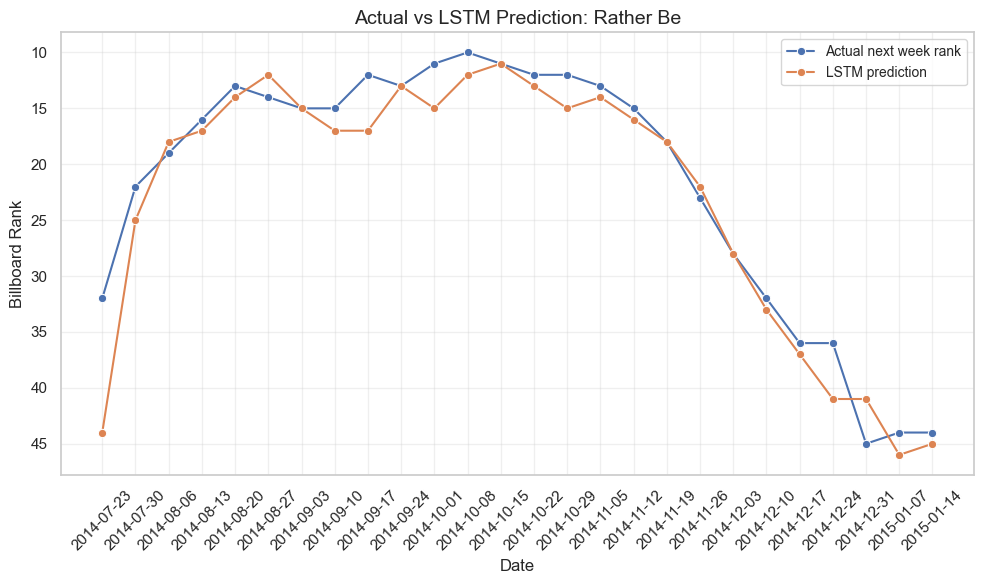

In [40]:

y_pred_rank = np.round(y_pred)
y_pred_rank = np.clip(y_pred_rank, 1, 100)
y_pred_rank = y_pred_rank.astype(int)
plot_song_prediction_comparison_lstm(
    test_meta,
    song_name="Rather Be",
    y_pred=y_pred_rank
)

In [ ]:
#plot loss curves
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')

plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['mae'], label='Training MAE')
plt.plot(history.history['val_mae'], label='Validation MAE')
plt.title('Training MAE')
plt.xlabel('Epoch')
plt.ylabel('MAE')
plt.legend()
plt.tight_layout()

plt.show()

PLOT XGBOOST RESULTS

In [49]:
xgboost_data['Date'] = pd.to_datetime(xgboost_data['Date'])
test_data = xgboost_data[xgboost_data['Date'] >= '2014-01-01']

xgb_features = [
     'Rank','Last Week', 'rolling_avg_4_weeks', 'rank_change', 'rolling_std_4_weeks', 'Weeks in Charts']
y_pred_xgb = xgboost_model.predict(test_data[xgb_features])

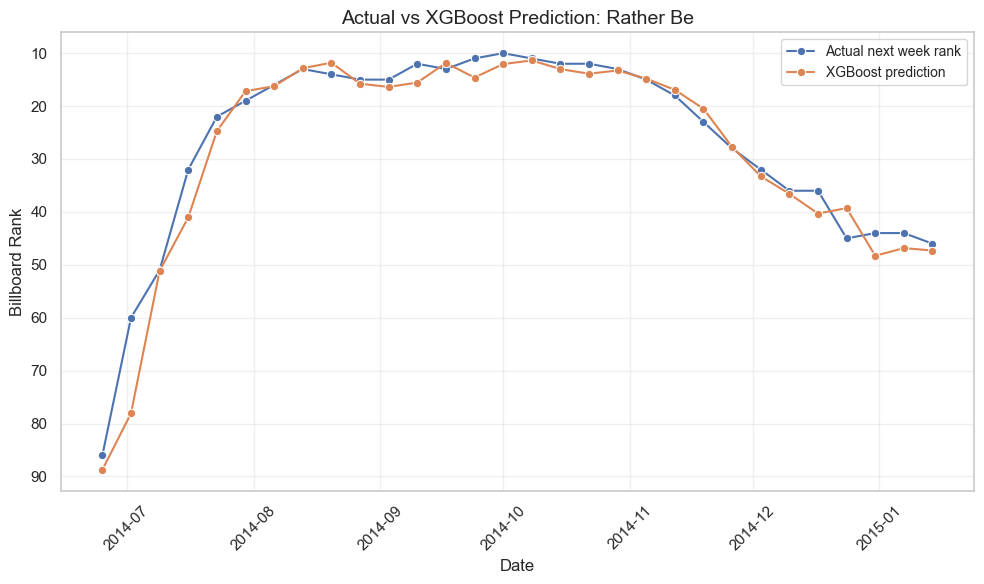

In [52]:
plot_song_prediction_comparison(test_data, 'Rather Be', y_pred_xgb)

COMPARE BOTH MODELS


In [70]:
data_original = pd.read_csv("../../Data/processed_forecast_data.csv")
groups = data_original.groupby(['Song', 'Artist'])

X = []
X_xgb = []
y = []
target_dates = []
meta = []
xgboost_features = [
    'Rank', 'Last Week', 'rolling_avg_4_weeks', 'rank_change', 'rolling_std_4_weeks', 'Weeks in Charts'
]
for (song, artist), group in groups:
    group = group.sort_values('Date')

    data_lstm = group[features].values
    data_xgb = group[xgboost_features].values
    ranks = group['Rank'].values
    dates = group['Date'].values

    for i in range(len(group) - SEQ_LEN):
        X_seq = data_lstm[i:i+SEQ_LEN]
        X_xgb_seq = data_xgb[i:i+SEQ_LEN]
        y_target = ranks[i+SEQ_LEN]

        X.append(X_seq)
        y.append(y_target)
        target_dates.append(dates[i+SEQ_LEN])

        X_xgb.append(data_xgb[i+SEQ_LEN-1])

        meta.append({
            'Song': song,
            'Artist': artist,
            'Date': dates[i+SEQ_LEN],
            'target_next_rank': y_target
        })

X = np.array(X)
X_xgb = np.array(X_xgb)
y = np.array(y)
target_dates = np.array(target_dates)
meta = pd.DataFrame(meta)

In [71]:
target_dates = pd.to_datetime(target_dates)
threshold_date = pd.to_datetime("2014-01-01") 

train_mask = target_dates < threshold_date
test_mask = target_dates >= threshold_date

X_train = X[train_mask]
X_test = X[test_mask]

X_xgb_train = X_xgb[train_mask]
X_xgb_test = X_xgb[test_mask]

y_train = y[train_mask]
y_test = y[test_mask]

test_meta = meta[test_mask].reset_index(drop=True)


In [72]:

scaler = MinMaxScaler()

samples_train, timesteps, features_count = X_train.shape
samples_test = X_test.shape[0]

X_train_2d = X_train.reshape(-1, features_count)
X_test_2d = X_test.reshape(-1, features_count)

X_train = scaler.fit_transform(X_train_2d).reshape(samples_train, timesteps, features_count)
X_test = scaler.transform(X_test_2d).reshape(samples_test, timesteps, features_count)

In [73]:
y_pred_lstm_scaled = lstm_model.predict(X_test)
y_pred_lstm = y_scaler.inverse_transform(y_pred_lstm_scaled).reshape(-1)
y_pred_xgb = xgboost_model.predict(X_xgb_test)

660/660 ━━━━━━━━━━━━━━━━━━━━ 1s 779us/step


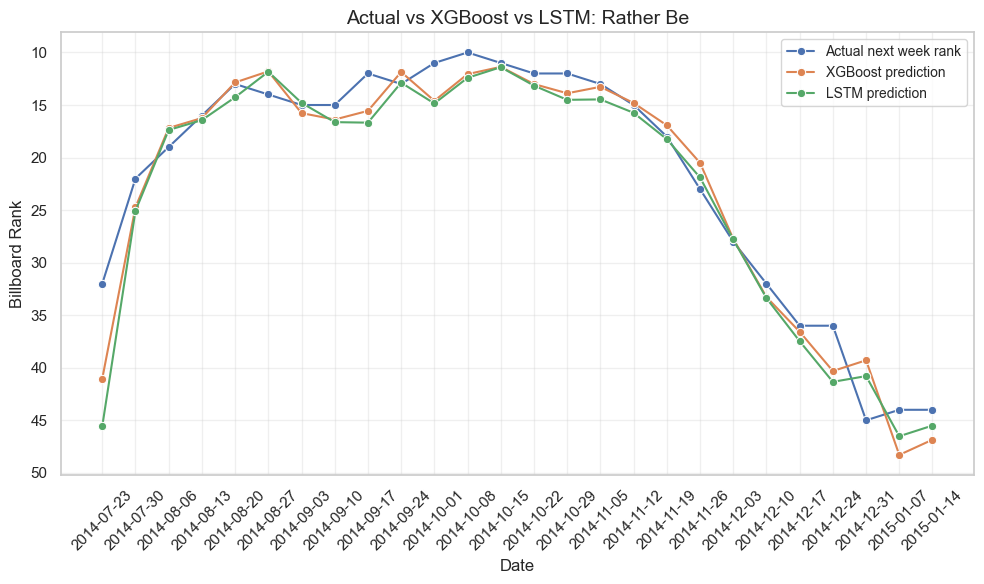

In [75]:
plot_xgboost_lstm_comparison(
    xgb_test_data=test_meta,
    lstm_test_meta=test_meta,
    song_name="Rather Be",
    xgb_pred=y_pred_xgb,
    lstm_pred=y_pred_lstm
)